Memulai pembuatan data sintetik untuk seluruh Kelas AVO...
[OK] Master Dataset (4 Kelas) tersimpan: dataset_seismik_ml_lengkap\avo_master_dataset.npz
[OK] Master SEG-Y tersimpan: dataset_seismik_ml_lengkap\avo_all_classes_noisy.sgy
Menampilkan Dashboard Visualisasi...


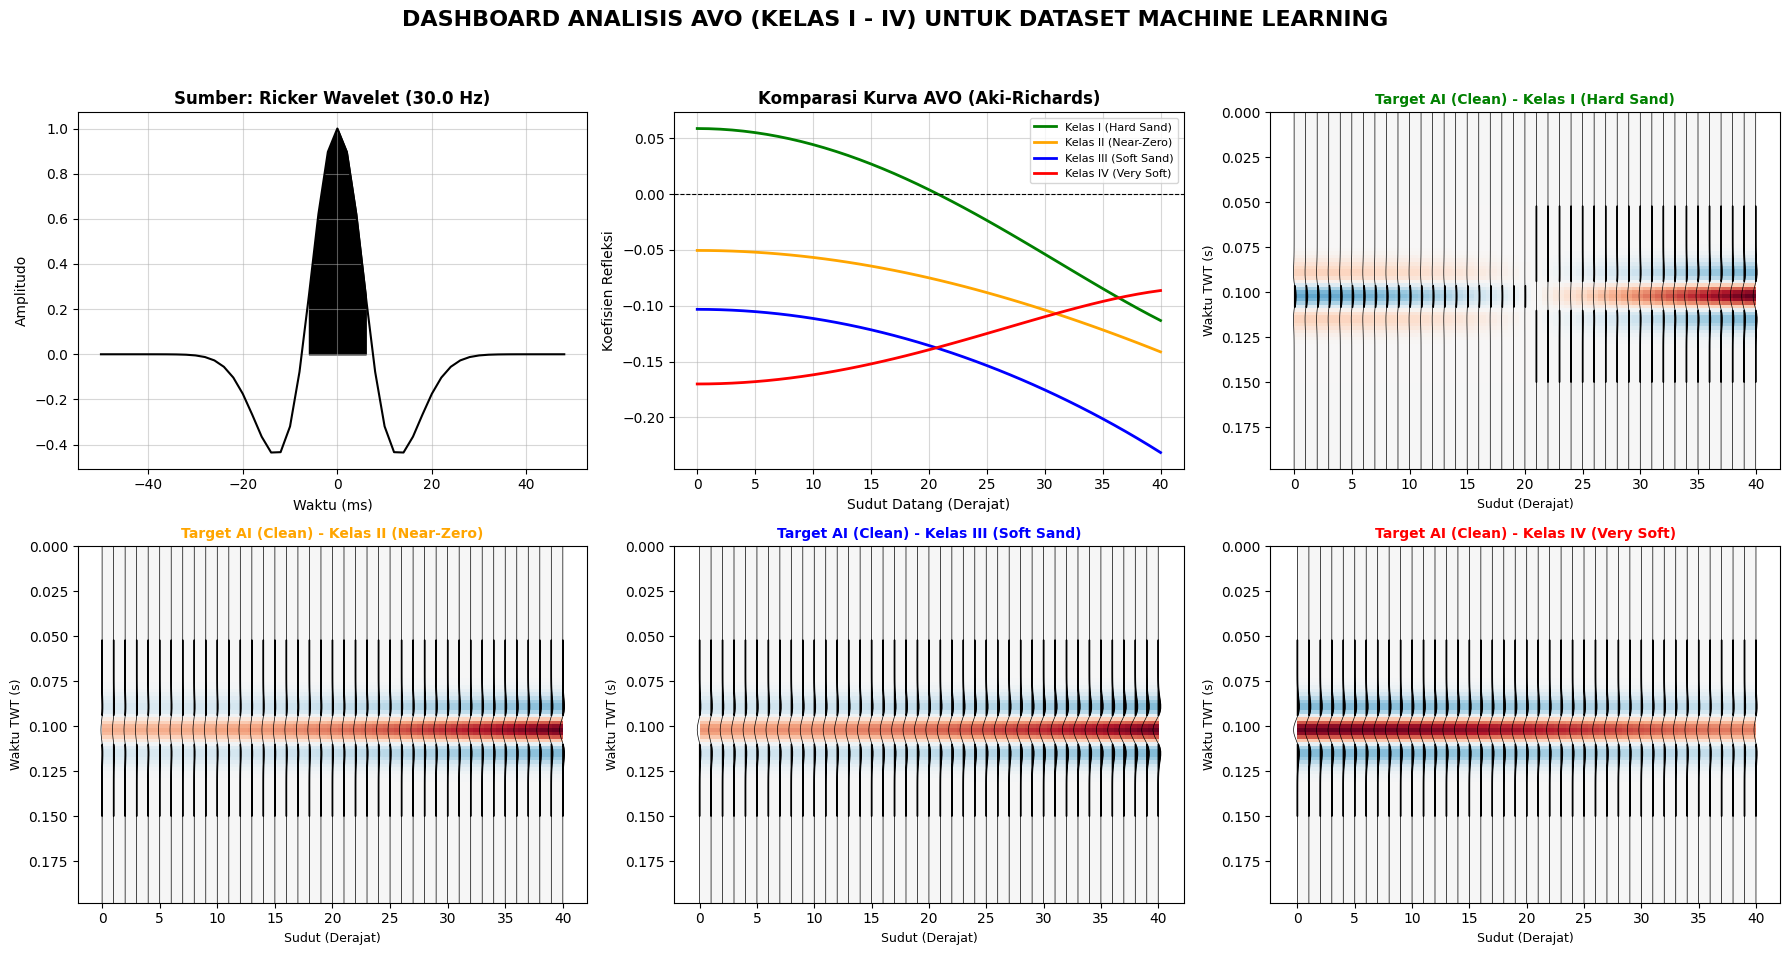

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Memastikan segyio tersedia
try:
    import segyio
    SEGYIO_AVAILABLE = True
except ImportError:
    SEGYIO_AVAILABLE = False
    print("Peringatan: Modul 'segyio' tidak ditemukan. Ekspor ke format SEG-Y akan dilewati.")

# ==========================================
# BAGIAN 1: FUNGSI MATEMATIS & GEOFISIKA
# ==========================================

def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

def aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, theta_deg):
    theta_rad = np.radians(theta_deg)
    
    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1
    
    vp = (vp1 + vp2) / 2.0
    vs = (vs1 + vs2) / 2.0
    rho = (rho1 + rho2) / 2.0
    
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    C = 0.5 * (dvp/vp)
    
    R_theta = A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2 * np.tan(theta_rad)**2)
    return R_theta

def plot_seismic_gather(ax, data, angles, dt, title):
    n_samples = data.shape[0]
    time_vector = np.arange(0, n_samples * dt, dt)
    vmax = np.max(np.abs(data)) if np.max(np.abs(data)) != 0 else 1.0
    
    im = ax.imshow(data, aspect='auto', cmap='RdBu', 
                   extent=[angles[0], angles[-1], time_vector[-1], time_vector[0]],
                   vmin=-vmax, vmax=vmax)
    
    scaling_factor = 2.0 
    for i, angle in enumerate(angles):
        trace = data[:, i]
        shifted_trace = angle + trace * scaling_factor
        ax.plot(shifted_trace, time_vector, color='black', linewidth=0.5)
        ax.fill_betweenx(time_vector, angle, shifted_trace, 
                         where=(trace > 0), color='black')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Sudut (Derajat)', fontsize=9)
    ax.set_ylabel('Waktu TWT (s)', fontsize=9)
    return im

# ==========================================
# BAGIAN 2: DATABASE PETROFISIKA (KELAS I - IV)
# ==========================================

dt = 0.002
n_samples = 100
target_idx = 50
angles = np.arange(0, 41, 1)
frekuensi_sumber = 30.0
snr_db = 10

# Parameter Dunia Nyata untuk 4 Kelas AVO (Shale -> Gas Sand)
avo_classes = {
    'Kelas I (Hard Sand)':  {'vp1': 3000, 'vs1': 1400, 'rho1': 2.40, 'vp2': 3600, 'vs2': 2300, 'rho2': 2.25},
    'Kelas II (Near-Zero)': {'vp1': 2900, 'vs1': 1400, 'rho1': 2.35, 'vp2': 2800, 'vs2': 1700, 'rho2': 2.20},
    'Kelas III (Soft Sand)':{'vp1': 2700, 'vs1': 1300, 'rho1': 2.35, 'vp2': 2400, 'vs2': 1600, 'rho2': 2.15},
    'Kelas IV (Very Soft)': {'vp1': 3200, 'vs1': 1600, 'rho1': 2.40, 'vp2': 2600, 'vs2': 1100, 'rho2': 2.10}
}

# ==========================================
# BAGIAN 3: GENERATE DATA UNTUK SEMUA KELAS
# ==========================================

print("Memulai pembuatan data sintetik untuk seluruh Kelas AVO...")

t_wav, wavelet = ricker_wavelet(frekuensi_sumber, dt, 0.1)

# Dictionary untuk menyimpan hasil
results_r_theta = {}
results_clean = {}
results_noisy = {}

for cls_name, params in avo_classes.items():
    # 1. Hitung Koefisien Refleksi
    R_theta = aki_richards_avo(params['vp1'], params['vs1'], params['rho1'], 
                               params['vp2'], params['vs2'], params['rho2'], angles)
    results_r_theta[cls_name] = R_theta
    
    # 2. Matriks Reflektivitas & Konvolusi
    reflectivity_matrix = np.zeros((n_samples, len(angles)))
    reflectivity_matrix[target_idx, :] = R_theta
    
    synthetic_clean = np.zeros_like(reflectivity_matrix)
    for i in range(len(angles)):
        synthetic_clean[:, i] = np.convolve(reflectivity_matrix[:, i], wavelet, mode='same')
    results_clean[cls_name] = synthetic_clean
    
    # 3. Penambahan Noise
    signal_power = np.mean(synthetic_clean**2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), synthetic_clean.shape)
    results_noisy[cls_name] = synthetic_clean + noise

# ==========================================
# BAGIAN 4: PENYIMPANAN DATA MASTER ML
# ==========================================

output_dir = "dataset_seismik_ml_lengkap"
os.makedirs(output_dir, exist_ok=True)

# Stack semua data menjadi format 3D [Jumlah_Kelas, Time_Samples, Angles]
# Ini adalah format ideal untuk dimasukkan ke CNN / BiLSTM
X_train_master = np.stack(list(results_noisy.values()), axis=0)
Y_train_master = np.stack(list(results_clean.values()), axis=0)

file_path_npz = os.path.join(output_dir, "avo_master_dataset.npz")
np.savez_compressed(file_path_npz, 
                    X_train=X_train_master, 
                    Y_train=Y_train_master, 
                    classes=list(avo_classes.keys()),
                    angles=angles, 
                    dt=dt)
print(f"[OK] Master Dataset (4 Kelas) tersimpan: {file_path_npz}")

# Ekspor SEG-Y (Menggabungkan semua kelas ke dalam 1 file, dibatasi secara sekuensial)
if SEGYIO_AVAILABLE:
    file_path_sgy = os.path.join(output_dir, "avo_all_classes_noisy.sgy")
    n_traces_per_class = len(angles)
    total_traces = n_traces_per_class * len(avo_classes)
    
    spec = segyio.spec()
    spec.sorting = 1
    spec.format = 1
    spec.samples = np.arange(0, n_samples * dt * 1000, dt * 1000)
    spec.tracecount = total_traces

    with segyio.create(file_path_sgy, spec) as f:
        trace_idx = 0
        for cls_name, data_noisy in results_noisy.items():
            for i in range(len(angles)):
                f.trace[trace_idx] = data_noisy[:, i].astype(np.float32)
                f.header[trace_idx] = {
                    segyio.su.offset: int(angles[i]),
                    segyio.su.tracl: trace_idx + 1,
                    segyio.su.cdp: list(avo_classes.keys()).index(cls_name) + 1 # Penanda Kelas di CDP
                }
                trace_idx += 1
    print(f"[OK] Master SEG-Y tersimpan: {file_path_sgy}")

# ==========================================
# BAGIAN 5: DASHBOARD VISUALISASI 2x3
# ==========================================

print("Menampilkan Dashboard Visualisasi...")

fig = plt.figure(figsize=(18, 10))
plt.suptitle("DASHBOARD ANALISIS AVO (KELAS I - IV) UNTUK DATASET MACHINE LEARNING", fontsize=16, fontweight='bold')

# Panel 1 (Kiri Atas): Ricker Wavelet
ax1 = plt.subplot(2, 3, 1)
ax1.plot(t_wav * 1000, wavelet, color='black', linewidth=1.5)
ax1.fill_between(t_wav * 1000, wavelet, 0, where=(wavelet > 0), color='black')
ax1.set_title(f'Sumber: Ricker Wavelet ({frekuensi_sumber} Hz)', fontweight='bold')
ax1.set_xlabel('Waktu (ms)')
ax1.set_ylabel('Amplitudo')
ax1.grid(True, alpha=0.5)

# Panel 2 (Tengah Atas): Kurva AVO Overlay 4 Kelas
ax2 = plt.subplot(2, 3, 2)
colors = ['green', 'orange', 'blue', 'red']
for (cls_name, R_th), color in zip(results_r_theta.items(), colors):
    ax2.plot(angles, R_th, label=cls_name, color=color, linewidth=2)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Komparasi Kurva AVO (Aki-Richards)', fontweight='bold')
ax2.set_xlabel('Sudut Datang (Derajat)')
ax2.set_ylabel('Koefisien Refleksi')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.5)

# Panel 3-6: Plot Gather Seismik (Clean) untuk Tiap Kelas
# Agar AI Anda tahu perbedaan "Kunci Jawaban" untuk setiap geologi
axes_gathers = [plt.subplot(2, 3, 3), plt.subplot(2, 3, 4), plt.subplot(2, 3, 5), plt.subplot(2, 3, 6)]

for ax, (cls_name, data_clean), color in zip(axes_gathers, results_clean.items(), colors):
    plot_seismic_gather(ax, data_clean, angles, dt, f'Target AI (Clean) - {cls_name}')
    # Memberi aksen warna pada judul agar sesuai dengan warna kurva
    ax.title.set_color(color)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Menyesuaikan spasi untuk suptitle
plt.show()

Memulai pembuatan data sintetik untuk seluruh Kelas AVO...
[OK] Master Dataset (4 Kelas) tersimpan: dataset_seismik_ml_lengkap\avo_master_dataset.npz
[OK] Master SEG-Y tersimpan: dataset_seismik_ml_lengkap\avo_all_classes_noisy.sgy
Menampilkan Dashboard Visualisasi...


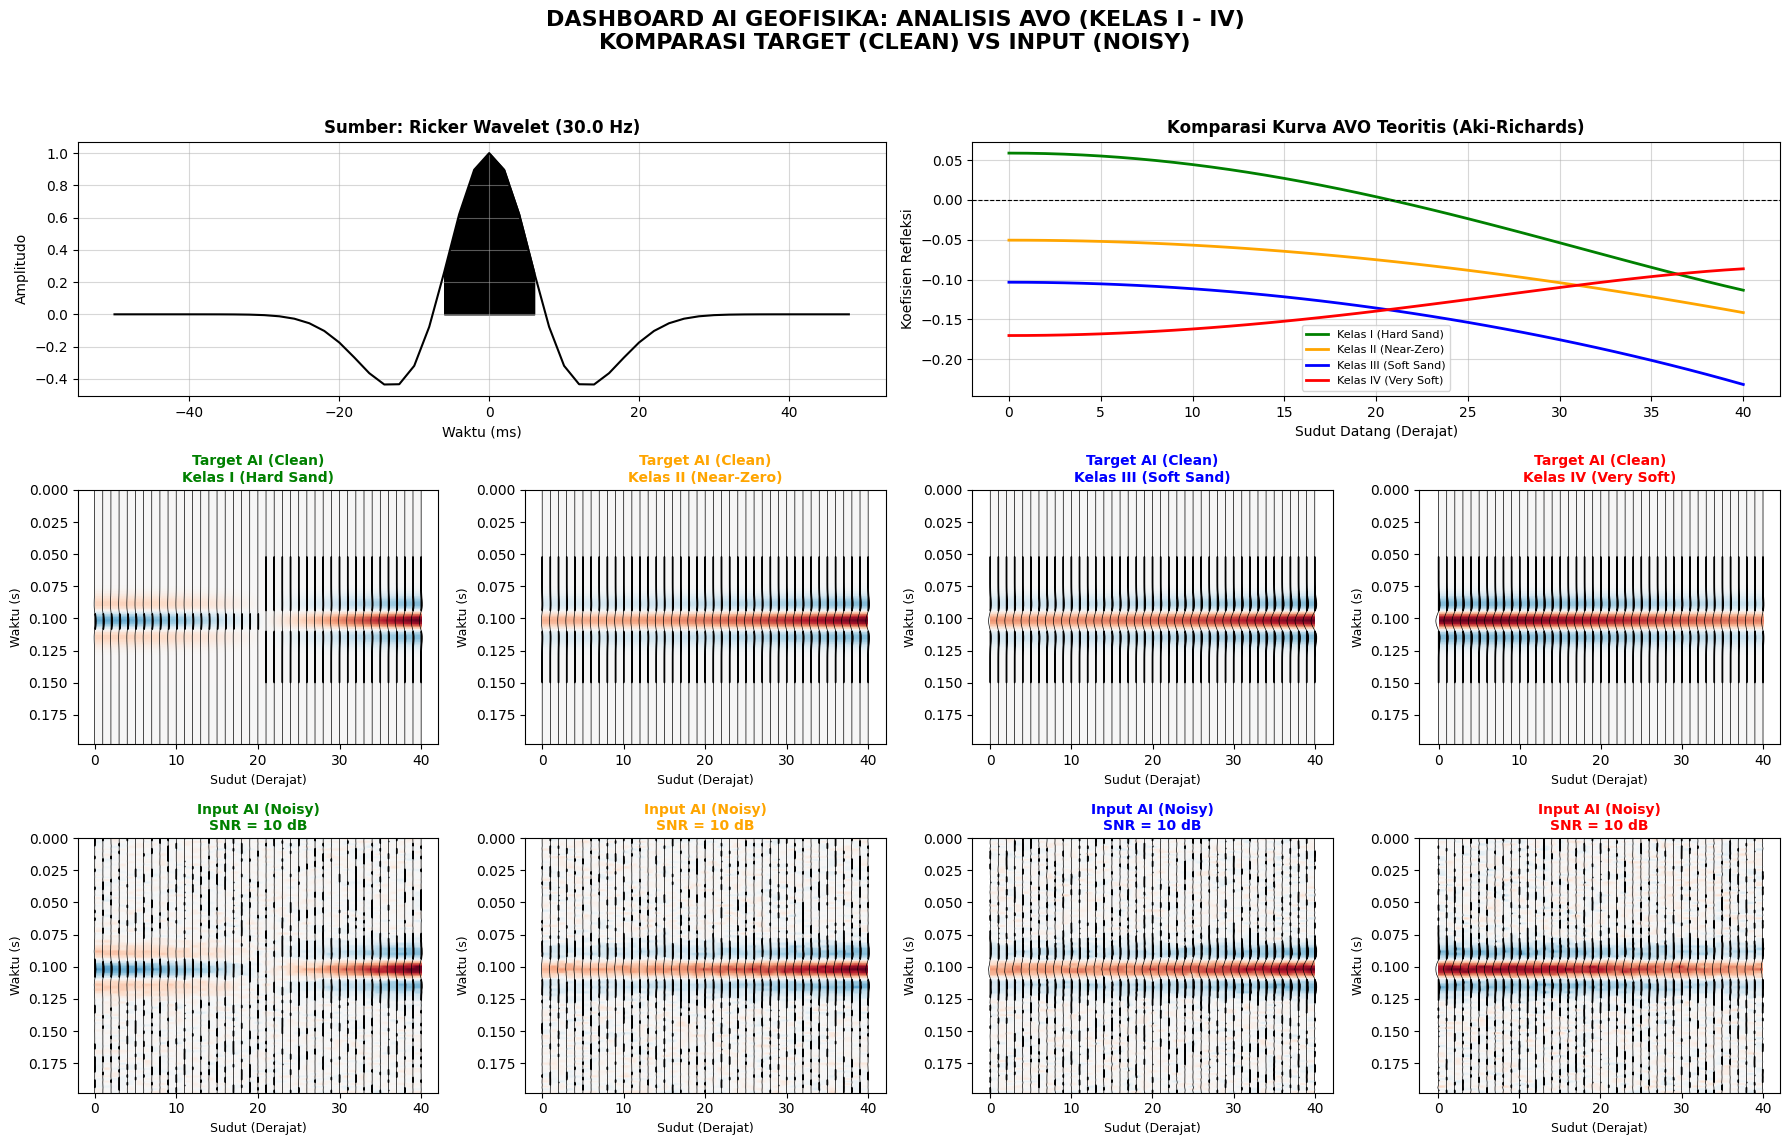

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Memastikan segyio tersedia
try:
    import segyio
    SEGYIO_AVAILABLE = True
except ImportError:
    SEGYIO_AVAILABLE = False
    print("Peringatan: Modul 'segyio' tidak ditemukan. Ekspor ke format SEG-Y akan dilewati.")

# ==========================================
# BAGIAN 1: FUNGSI MATEMATIS & GEOFISIKA
# ==========================================

def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

def aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, theta_deg):
    theta_rad = np.radians(theta_deg)
    
    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1
    
    vp = (vp1 + vp2) / 2.0
    vs = (vs1 + vs2) / 2.0
    rho = (rho1 + rho2) / 2.0
    
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    C = 0.5 * (dvp/vp)
    
    R_theta = A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2 * np.tan(theta_rad)**2)
    return R_theta

def plot_seismic_gather(ax, data, angles, dt, title):
    n_samples = data.shape[0]
    time_vector = np.arange(0, n_samples * dt, dt)
    vmax = np.max(np.abs(data)) if np.max(np.abs(data)) != 0 else 1.0
    
    im = ax.imshow(data, aspect='auto', cmap='RdBu', 
                   extent=[angles[0], angles[-1], time_vector[-1], time_vector[0]],
                   vmin=-vmax, vmax=vmax)
    
    scaling_factor = 2.0 
    for i, angle in enumerate(angles):
        trace = data[:, i]
        shifted_trace = angle + trace * scaling_factor
        ax.plot(shifted_trace, time_vector, color='black', linewidth=0.5)
        ax.fill_betweenx(time_vector, angle, shifted_trace, 
                         where=(trace > 0), color='black')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Sudut (Derajat)', fontsize=9)
    ax.set_ylabel('Waktu (s)', fontsize=9)
    return im

# ==========================================
# BAGIAN 2: DATABASE PETROFISIKA (KELAS I - IV)
# ==========================================

dt = 0.002
n_samples = 100
target_idx = 50
angles = np.arange(0, 41, 1)
frekuensi_sumber = 30.0
snr_db = 10

# Parameter Dunia Nyata untuk 4 Kelas AVO (Shale -> Gas Sand)
avo_classes = {
    'Kelas I (Hard Sand)':  {'vp1': 3000, 'vs1': 1400, 'rho1': 2.40, 'vp2': 3600, 'vs2': 2300, 'rho2': 2.25},
    'Kelas II (Near-Zero)': {'vp1': 2900, 'vs1': 1400, 'rho1': 2.35, 'vp2': 2800, 'vs2': 1700, 'rho2': 2.20},
    'Kelas III (Soft Sand)':{'vp1': 2700, 'vs1': 1300, 'rho1': 2.35, 'vp2': 2400, 'vs2': 1600, 'rho2': 2.15},
    'Kelas IV (Very Soft)': {'vp1': 3200, 'vs1': 1600, 'rho1': 2.40, 'vp2': 2600, 'vs2': 1100, 'rho2': 2.10}
}

# ==========================================
# BAGIAN 3: GENERATE DATA UNTUK SEMUA KELAS
# ==========================================

print("Memulai pembuatan data sintetik untuk seluruh Kelas AVO...")

t_wav, wavelet = ricker_wavelet(frekuensi_sumber, dt, 0.1)

# Dictionary untuk menyimpan hasil
results_r_theta = {}
results_clean = {}
results_noisy = {}

for cls_name, params in avo_classes.items():
    # 1. Hitung Koefisien Refleksi
    R_theta = aki_richards_avo(params['vp1'], params['vs1'], params['rho1'], 
                               params['vp2'], params['vs2'], params['rho2'], angles)
    results_r_theta[cls_name] = R_theta
    
    # 2. Matriks Reflektivitas & Konvolusi
    reflectivity_matrix = np.zeros((n_samples, len(angles)))
    reflectivity_matrix[target_idx, :] = R_theta
    
    synthetic_clean = np.zeros_like(reflectivity_matrix)
    for i in range(len(angles)):
        synthetic_clean[:, i] = np.convolve(reflectivity_matrix[:, i], wavelet, mode='same')
    results_clean[cls_name] = synthetic_clean
    
    # 3. Penambahan Noise
    signal_power = np.mean(synthetic_clean**2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), synthetic_clean.shape)
    results_noisy[cls_name] = synthetic_clean + noise

# ==========================================
# BAGIAN 4: PENYIMPANAN DATA MASTER ML
# ==========================================

output_dir = "dataset_seismik_ml_lengkap"
os.makedirs(output_dir, exist_ok=True)

X_train_master = np.stack(list(results_noisy.values()), axis=0)
Y_train_master = np.stack(list(results_clean.values()), axis=0)

file_path_npz = os.path.join(output_dir, "avo_master_dataset.npz")
np.savez_compressed(file_path_npz, 
                    X_train=X_train_master, 
                    Y_train=Y_train_master, 
                    classes=list(avo_classes.keys()),
                    angles=angles, 
                    dt=dt)
print(f"[OK] Master Dataset (4 Kelas) tersimpan: {file_path_npz}")

if SEGYIO_AVAILABLE:
    file_path_sgy = os.path.join(output_dir, "avo_all_classes_noisy.sgy")
    n_traces_per_class = len(angles)
    total_traces = n_traces_per_class * len(avo_classes)
    
    spec = segyio.spec()
    spec.sorting = 1
    spec.format = 1
    spec.samples = np.arange(0, n_samples * dt * 1000, dt * 1000)
    spec.tracecount = total_traces

    with segyio.create(file_path_sgy, spec) as f:
        trace_idx = 0
        for cls_name, data_noisy in results_noisy.items():
            for i in range(len(angles)):
                f.trace[trace_idx] = data_noisy[:, i].astype(np.float32)
                f.header[trace_idx] = {
                    segyio.su.offset: int(angles[i]),
                    segyio.su.tracl: trace_idx + 1,
                    segyio.su.cdp: list(avo_classes.keys()).index(cls_name) + 1
                }
                trace_idx += 1
    print(f"[OK] Master SEG-Y tersimpan: {file_path_sgy}")

# ==========================================
# BAGIAN 5: DASHBOARD VISUALISASI KOMPREHENSIF
# ==========================================

print("Menampilkan Dashboard Visualisasi...")

# Menggunakan ukuran figure yang lebih besar untuk matriks 3 baris x 4 kolom
fig = plt.figure(figsize=(18, 12))
plt.suptitle("DASHBOARD AI GEOFISIKA: ANALISIS AVO (KELAS I - IV)\nKOMPARASI TARGET (CLEAN) VS INPUT (NOISY)", 
             fontsize=16, fontweight='bold')

# --- BARIS 1: Sumber dan Analisis Teoretis ---
# Kolom 1-2 digabung untuk Ricker Wavelet
ax_wav = plt.subplot2grid((3, 4), (0, 0), colspan=2)
ax_wav.plot(t_wav * 1000, wavelet, color='black', linewidth=1.5)
ax_wav.fill_between(t_wav * 1000, wavelet, 0, where=(wavelet > 0), color='black')
ax_wav.set_title(f'Sumber: Ricker Wavelet ({frekuensi_sumber} Hz)', fontweight='bold')
ax_wav.set_xlabel('Waktu (ms)')
ax_wav.set_ylabel('Amplitudo')
ax_wav.grid(True, alpha=0.5)

# Kolom 3-4 digabung untuk Kurva AVO
ax_avo = plt.subplot2grid((3, 4), (0, 2), colspan=2)
colors = ['green', 'orange', 'blue', 'red']
for (cls_name, R_th), color in zip(results_r_theta.items(), colors):
    ax_avo.plot(angles, R_th, label=cls_name, color=color, linewidth=2)
ax_avo.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_avo.set_title('Komparasi Kurva AVO Teoritis (Aki-Richards)', fontweight='bold')
ax_avo.set_xlabel('Sudut Datang (Derajat)')
ax_avo.set_ylabel('Koefisien Refleksi')
ax_avo.legend(loc='best', fontsize=8)
ax_avo.grid(True, alpha=0.5)

# --- BARIS 2 & 3: Visualisasi Gather (Clean & Noisy) ---
for idx, (cls_name, color) in enumerate(zip(avo_classes.keys(), colors)):
    
    # BARIS 2: Target ML (Clean)
    ax_clean = plt.subplot2grid((3, 4), (1, idx))
    plot_seismic_gather(ax_clean, results_clean[cls_name], angles, dt, f'Target AI (Clean)\n{cls_name}')
    ax_clean.title.set_color(color) # Aksentuasi warna judul sesuai kurva
    
    # BARIS 3: Input ML (Noisy)
    ax_noisy = plt.subplot2grid((3, 4), (2, idx))
    plot_seismic_gather(ax_noisy, results_noisy[cls_name], angles, dt, f'Input AI (Noisy)\nSNR = {snr_db} dB')
    ax_noisy.title.set_color(color)

# Menyesuaikan margin agar rapi
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# BAGIAN 1: FUNGSI GEOFISIKA (Sama seperti Training)
# ==========================================
def ricker_wavelet(f, dt, length):
    t = np.arange(-length/2, (length-dt)/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

def aki_richards_avo(vp1, vs1, rho1, vp2, vs2, rho2, theta_deg):
    theta_rad = np.radians(theta_deg)
    dvp, dvs, drho = vp2 - vp1, vs2 - vs1, rho2 - rho1
    vp, vs, rho = (vp1 + vp2) / 2.0, (vs1 + vs2) / 2.0, (rho1 + rho2) / 2.0
    A = 0.5 * (dvp/vp + drho/rho)
    B = 0.5 * (dvp/vp) - 4 * (vs/vp)**2 * (dvs/vs) - 2 * (vs/vp)**2 * (drho/rho)
    C = 0.5 * (dvp/vp)
    return A + B * np.sin(theta_rad)**2 + C * (np.sin(theta_rad)**2 * np.tan(theta_rad)**2)

# ==========================================
# BAGIAN 2: PARAMETER "BLIND TEST" (BERBEDA DARI TRAINING)
# ==========================================
dt = 0.002
n_samples = 100
target_idx = 50
angles = np.arange(0, 41, 1)

# PERUBAHAN 1: Frekuensi sumber lebih tinggi (misal dari vibroseis yang berbeda)
frekuensi_test = 35.0  # Sebelumnya 30.0 Hz
# PERUBAHAN 2: Noise sedikit lebih besar (kondisi lapangan lebih buruk)
snr_test_db = 8        # Sebelumnya 10 dB

# PERUBAHAN 3: Variasi Petrofisika (Mensimulasikan sumur berbeda)
# Nilainya digeser agar AI tidak menghafal angka mutlak, melainkan pola kurvanya.
avo_test_classes = {
    'Test Kelas I (Harder Sand)':  {'vp1': 3100, 'vs1': 1500, 'rho1': 2.45, 'vp2': 3700, 'vs2': 2400, 'rho2': 2.30},
    'Test Kelas II (Shifted)':     {'vp1': 2850, 'vs1': 1350, 'rho1': 2.33, 'vp2': 2800, 'vs2': 1750, 'rho2': 2.25},
    'Test Kelas III (Softer Sand)':{'vp1': 2600, 'vs1': 1200, 'rho1': 2.30, 'vp2': 2200, 'vs2': 1500, 'rho2': 2.10},
    'Test Kelas IV (Extreme Drop)':{'vp1': 3300, 'vs1': 1700, 'rho1': 2.45, 'vp2': 2500, 'vs2': 1050, 'rho2': 2.05}
}

# ==========================================
# BAGIAN 3: GENERATE DATA BLIND TEST
# ==========================================
print("Membangun Blind Test Dataset...")
t_wav, wavelet = ricker_wavelet(frekuensi_test, dt, 0.1)

test_clean = {}
test_noisy = {}

for cls_name, params in avo_test_classes.items():
    R_theta = aki_richards_avo(params['vp1'], params['vs1'], params['rho1'], 
                               params['vp2'], params['vs2'], params['rho2'], angles)
    
    reflectivity = np.zeros((n_samples, len(angles)))
    reflectivity[target_idx, :] = R_theta
    
    clean_gather = np.zeros_like(reflectivity)
    for i in range(len(angles)):
        clean_gather[:, i] = np.convolve(reflectivity[:, i], wavelet, mode='same')
    test_clean[cls_name] = clean_gather
    
    signal_power = np.mean(clean_gather**2)
    noise_power = signal_power / (10 ** (snr_test_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), clean_gather.shape)
    test_noisy[cls_name] = clean_gather + noise

# ==========================================
# BAGIAN 4: PENYIMPANAN DATA TEST
# ==========================================
output_dir = "dataset_seismik_ml_lengkap"
os.makedirs(output_dir, exist_ok=True)

X_test_master = np.stack(list(test_noisy.values()), axis=0)
Y_test_master = np.stack(list(test_clean.values()), axis=0)

file_path_test = os.path.join(output_dir, "avo_blind_test_dataset.npz")
np.savez_compressed(file_path_test, 
                    X_test=X_test_master, 
                    Y_test=Y_test_master, 
                    classes=list(avo_test_classes.keys()),
                    angles=angles, 
                    dt=dt)

print(f"[OK] Blind Test Dataset tersimpan: {file_path_test}")
print(f"Shape X_test (Input): {X_test_master.shape}")
print(f"Shape Y_test (Target): {Y_test_master.shape}")

Membangun Blind Test Dataset...
[OK] Blind Test Dataset tersimpan: dataset_seismik_ml_lengkap\avo_blind_test_dataset.npz
Shape X_test (Input): (4, 100, 41)
Shape Y_test (Target): (4, 100, 41)
